In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [ ]:
!pwd

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


#RNN 활용하기 : 네이버 영화 리뷰 데이터 감성분석

word단위로 학습하기
- 데이터 로딩
- 결측치 제거
- 문제, 답 분리

In [ ]:
# 데이터 로딩
import pandas as pd
train_df = pd.read_csv('./data/ratings_train.txt',delimiter='\t')
test_df = pd.read_csv('./data/ratings_test.txt',delimiter='\t')

In [ ]:
train_df.info() # 결측치 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [ ]:
# 결측치 제거
train_df.dropna(inplace = True)
test_df.dropna(inplace = True)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49997 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        49997 non-null  int64 
 1   document  49997 non-null  object
 2   label     49997 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.5+ MB


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149995 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        149995 non-null  int64 
 1   document  149995 non-null  object
 2   label     149995 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


### 학습을 위한 전처리
- 특수문자 제거
- 불용어 제거
- 형태소 분리 (어간 추출 + 정규화)
- 인코딩(라벨인코딩 방식 활용) + 길이(순환 횟수) 맞추기

In [ ]:
import re

In [ ]:
# 특수문자 제거를 위한 정규표현식 패턴 설정
pattern = re.compile(r'[^a-zA-Z0-9가-힇\s\.\?\!]')
# Ws : 공백 문자(스페이스, 탭, 줄바꿈 등)

In [ ]:
example_review = '    오늘 영화 Review 평점은 10점 만점에 9.7!! 너무 재밌습니다. 👍😊 #꿀잼영화 #감동'

In [ ]:
# re.sub(정규 표현식, 문자열, 바꿀 대상, 문자열) : 문자열 치환 함수
re.sub(pattern,"",example_review)

'    오늘 영화 Review 평점은 10점 만점에 9.7!! 너무 재밌습니다.  꿀잼영화 감동'

In [ ]:
!pip -q install konlpy kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 41.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 26.5 MB/s eta 0:00:00


In [ ]:
from kiwipiepy.utils import Stopwords
# 불용어 : 자주 등장하지만 분석에 큰 의미가 없는 단어들

In [ ]:
stopwords = Stopwords()

In [ ]:
# 등록되어 있는 불용어 확인
print(stopwords.stopwords)

{('대하', 'VV'), ('부터', 'JX'), ('이', 'VCP'), ('그', 'NP'), ('겠', 'EP'), ('은', 'JX'), ('까지', 'JX'), ('라는', 'ETM'), ('ᆫ', 'ETM'), ('며', 'EC'), ('수', 'NNB'), ('있', 'VX'), ('보', 'VV'), ('과', 'JC'), ('과', 'JKB'), ('것', 'NNB'), ('지', 'VX'), ('되', 'VV'), ('더', 'MAG'), ('와', 'JC'), ('와', 'JKB'), ('통하', 'VV'), ('하', 'XSV'), ('ᆫ', 'JX'), ('에게', 'JKB'), ('으로', 'JKB'), ('다', 'EC'), ('고', 'JKQ'), ('로', 'JKB'), ('가', 'JKS'), ('하', 'VX'), ('때', 'NNG'), ('있', 'VV'), ('었', 'EP'), ('주', 'VX'), ('라', 'EC'), ('만', 'JX'), ('위하', 'VV'), ('면서', 'EC'), ('않', 'VX'), ('하', 'VV'), ('를', 'JKO'), ('도', 'JX'), ('제', 'XPN'), ('화', 'XSN'), ('고', 'EC'), ('들', 'XSN'), ('이', 'JKS'), ('나', 'NP'), ('다', 'EF'), ('는', 'ETM'), ('을', 'ETM'), ('면', 'EC'), ('때문', 'NNB'), ('게', 'EC'), ('지역', 'NNG'), ('받', 'VV'), ('지만', 'EC'), ('만', 'NR'), ('ᆯ', 'ETM'), ('명', 'NNB'), ('이', 'MM'), ('는', 'JX'), ('어야', 'EC'), ('원', 'NNB'), ('이', 'JKC'), ('일', 'NNB'), ('에', 'JKB'), ('우리', 'NP'), ('을', 'JKO'), ('성', 'XSN'), ('의', 'JKG'), ('말', 'NNG'), ('

In [ ]:
stopwords_list = [ word for word, tag in stopwords.stopwords]

# 그냥 for문써도 되지만 한줄 for문도 됨
# stopwords_list=[]
# for word, tag in stopwords.stopwords:
#  stopwords_list.append(word)

In [ ]:
print(stopwords_list)

['대하', '부터', '이', '그', '겠', '은', '까지', '라는', 'ᆫ', '며', '수', '있', '보', '과', '과', '것', '지', '되', '더', '와', '와', '통하', '하', 'ᆫ', '에게', '으로', '다', '고', '로', '가', '하', '때', '있', '었', '주', '라', '만', '위하', '면서', '않', '하', '를', '도', '제', '화', '고', '들', '이', '나', '다', '는', '을', '면', '때문', '게', '지역', '받', '지만', '만', 'ᆯ', '명', '이', '는', '어야', '원', '이', '일', '에', '우리', '을', '성', '의', '말', '지', '사람', '어서', '적', '다는', '어', '어', '그', 'ᆫ다', '던', '하', '같', '아니', '중', '한', '에서', '등', '다고', '따르', '은', '이', '월', '일', '년', '기', '없', '되']


In [ ]:
from konlpy.tag import Okt

In [ ]:
okt = Okt()

In [ ]:
# v품사 태깅(pos tagging) 예시
temp = okt.pos('이런것도된다곸ㅋㅋㅋㅋㅋ',
        stem = True, # 어간 추출(먹었다, 먹었음, 먹었어요 -> '먹다)
        norm = True # 정규화(입력 문장을 표준화 된 형태소로 변환하거나 비표준표현 삭제)
        )
temp

[('이런', 'Modifier'),
 ('것', 'Noun'),
 ('도', 'Josa'),
 ('되다', 'Verb'),
 ('ㅋㅋㅋ', 'KoreanParticle')]

In [ ]:
okt.tagset
# Noun(명사), Adjective(형용사), Verb(동사) 선택

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [ ]:
# 전처리 함수 정의
def proprocess_text(text):
  # 1. 특수문자 제거, 소문자 변환, 양쪽 끝 공백 제거
  text = re.sub(pattern,'',text).lower().strip()
#lower = 대소문자 구별 x , strip = 공백제거
  # 2. 형태소 분석 (어간 추출 + 정규화)
  pos_tags = okt.pos(text, stem = True, norm = True)

  # 3.명사, 형용사, 동사만 남기고. kiwi의 Stopwords에 있는 불용어는 필터링
  tokens = [
      word for word, tag in pos_tags
      if tag in ['Noun','Adjective','Verb']
      and word not in stopwords_list
  ]
  return ' '.join(tokens) # 공백으로 이어서 문자열로 변환

In [ ]:
from tqdm.auto import tqdm

In [ ]:
tqdm.pandas()

In [ ]:
X_train_clean = train_df['document'].progress_apply(proprocess_text)
X_test_clean = test_df['document'].progress_apply(proprocess_text)

  0%|          | 0/149995 [00:00<?, ?it/s]

  0%|          | 0/49997 [00:00<?, ?it/s]

In [ ]:
X_test_clean

,document
0,더빙 진짜 짜증나다 목소리
1,흠 포스터 보고 초딩 영화 줄 오버 연기 가볍다 않다
2,무재 밓었 다그 래서 보다 추천
3,교도소 이야기 구먼 솔직 재미 없다 평점 조정
4,몬페 익살스럽다 연기 돋보이다 영화 스파이더맨 늙다 보이다 하다 커스틴 던스트 이쁘...
...,...
149995,인간 문제 소 죄인
149996,평점 낮다
149997,뭐 한국인 거들다 먹거리 필리핀 혼혈 착하다
149998,청춘 영화 최고봉 방황 우울하다 날 자화상


In [ ]:
# label 분리
y_train = train_df['label']
y_test = test_df['label']

In [ ]:
y_train.shape, y_test.shape

((149995,), (49997,))

## 전처리 완료된 데이터 저장

In [ ]:
import pickle

In [ ]:
# 저장
with open('./data/X_train_morphs.pkl','wb') as f:
  pickle.dump(X_train_clean,f)
with open('./data/X_test_morphs.pkl','wb') as f:
  pickle.dump(X_test_clean,f)
with open('./data/y_train_morphs.pkl','wb') as f:
  pickle.dump(y_train_clean,f)
with open('./data/y_test_morphs.pkl','wb') as f:
  pickle.dump(y_test_clean,f)


# 데이터 로딩



In [ ]:
# 로딩
with open('./data/X_train_morphs.pkl','rb') as f:
  X_train_clean = pickle.load(f)
with open('./data/X_test_morphs.pkl','rb') as f:
  X_test_clean = pickle.load(f)
with open('./data/y_train_morphs.pkl','rb') as f:
  y_train = pickle.load(f)
with open('./data/y_test_morphs.pkl','rb') as f:
  y_test = pickle.load(f)

In [ ]:
X_test_clean.head()

,document
0,굳다
1,
2,뭐 평점 나쁘다 않다 점 짜다 리 더욱 아니다
3,지루하다 않다 완전 막장 임 돈 주다 보기
4,아니다 별 다섯 개 주다 왜 나오다 심기 불편하다 하다


In [ ]:
X_train_clean.shape, X_test_clean.shape

((149995,), (49997,))

In [ ]:
y_train

,label
0,0
1,1
2,0
3,0
4,1
...,...
149995,0
149996,1
149997,0
149998,1


In [ ]:
y_train.shape, y_test.shape

NameError: name 'y_train' is not defined

# 시퀀스 변환 준비
토큰화: 문장을 특정 기준에 맞춰 쪼개는 것
  - 글자단위, 단어단위(띄어쓰기), 형태소단위(명사,형용사,동사 등)

수치화 : 잘라진 토큰을 일정 기준(알고리즘)에 맞춰 숫자로    변경하는 것
  - 빈도인코딩, 원핫인코딩, 라벨인코딩, BOW,Tf-idf 등

In [ ]:
from tensorflow.keras.layers import TextVectorization
# 텍스트 데이터를 토큰화, 수치화로 학습용 데이터로 변경하는 클래스

In [ ]:
vectorizer = TextVectorization(
    # 사전에서 사용할 최대 단어 수 설정
    max_tokens = 5000,

    # 텍스트를 어떻게 변환할지 지정하는 옵션
    output_mode = 'int', # -> 텍스트를 정수 인덱스로 변환하여 각 단어에 해당하는 점수 출력

    # 텍스트 데이터를 표준화하는 방식 지정 (텍스트가 일관된 형식으로 정리됨)
    standardize = 'lower_and_strip_punctuation',    # 모두 소문자 변환, 구두점 제거

    # 출력되는 정수 스퀀스의 길이 고정 (짧으면 패딩(0)으로 채움, 길면 자름)
    output_sequence_length = 10

)

In [ ]:
# 훈련데이터 기반으로 전처리, 토큰화, 단어사전 구축 실시
vectorizer.adapt(X_train_clean)

In [ ]:
# 단어사전의 수 확인
vectorizer.vocabulary_size()

5000

In [ ]:
# 단어토큰 확인
print(vectorizer.get_vocabulary())
# UNK : 단어사전에 등록되지 않은 단어를 표현하는 토큰(unknown 토큰)

['', '[UNK]', '영화', '하다', '보다', '없다', '있다', '좋다', '재밌다', '정말', '되다', '진짜', '같다', '이다', '점', '아니다', '않다', '만들다', '나오다', '연기', '평점', '최고', '왜', '스토리', '생각', '드라마', '감동', '보고', '아깝다', '이렇다', '배우', '내', '재미있다', '거', '감독', '뭐', '들다', '재미', '내용', '그냥', '주다', '재미없다', '좀', '자다', '지루하다', '쓰레기', '시간', '가다', '모르다', '그렇다', '싶다', '작품', '알다', '사랑', '오다', '하나', '다시', '볼', '마지막', '완전', '처음', '정도', '많다', '장면', '액션', '주인공', '차다', '안되다', '최악', '나다', '지금', '돈', '걸', '이야기', '별로', '임', '느낌', '넘다', '연출', '개', '끝', '명작', '듯', '좋아하다', '역시', '받다', '남다', '이해', '괜찮다', '이영화', '안', '버리다', '또', '느끼다', '여자', '먹다', '아름답다', '해주다', '난', '편', '꼭', '보기', '기억', '결말', '어떻다', '마음', '인생', '아쉽다', '소재', '끄다', '애', '못', '보여주다', '뻔하다', '수준', '어리다', '재다', '무섭다', '현실', '맞다', '한번', '가장', '반전', '매력', '웃기다', '전개', '되어다', '남자', '한국', '끝나다', '가슴', '낮다', '말다', '슬프다', '높다', '죽다', '유치하다', '저', '알', '아이', '음악', '멋지다', '원작', '줄', '늘다', '인간', '쓰다', '무슨', '추천', '크다', '눈물', '함', '살다', '내다', '속', '야하다', '자체', '번', '허다', '눈', '찍다', '짜증나다', '솔직', 

In [ ]:
# 학습 데이터를 벡터화하여 정수,시퀀스로 변환
X_train_vec = vectorizer(X_train_clean)

In [ ]:
X_train_vec.shape

TensorShape([149995, 10])

In [ ]:
X_train_clean[0]

'더빙 진짜 짜증나다 목소리'

In [ ]:
X_train_vec[0]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([341,  11, 161, 503,   0,   0,   0,   0,   0,   0])>

In [ ]:
# test 데이터 변경
X_test_vec = vectorizer(X_test_clean)
X_test_vec.shape

TensorShape([49997, 10])

In [ ]:
import numpy as np

In [ ]:
# 입력 데이터를 shape를 (149995, 10, 1)변환 후 학습 필요
X_train_vec = np.expand_dims(X_train_vec,-1)
X_test_vec = np.expand_dims(X_test_vec,-1)  # -1 : 마지막 축(axis)에 새로운 차원 추가

In [ ]:
# 최종 모양 확인
X_train_vec.shape, X_test_vec.shape
# X_train_vec
# 약 15만개의 리뷰 데이터, 10개의 시퀀스 길이(순환 횟수), 벡터는 1개의 특성(정수 인덱스)

((149995, 10, 1, 1), (49997, 10, 1, 1))

## 학습
1. 모델 구조 정의
2. 학습방법 설정
3. 학습
4. 예측

In [ ]:
# !pip install numpy

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, InputLayer, SimpleRNN

In [ ]:
# 1. 모델 구조 정의
model = Sequential()
model.add(InputLayer(shape = (10,1)))
model.add(SimpleRNN(units = 64))
model.add(Dense(units = 1,activation='sigmoid'))
# 이진분류

In [ ]:
# 2.학습방법 설정
model.compile(loss = 'binary_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy'])

In [ ]:
# 3. 모델 학습
his_rnn = model.fit(X_train_vec,y_train,
                    epochs = 40,
                    batch_size = 128,
                    validation_split = 0.2)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5180 - loss: 0.6952 - val_accuracy: 0.5251 - val_loss: 0.6874
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5332 - loss: 0.6852 - val_accuracy: 0.5257 - val_loss: 0.6837
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5343 - loss: 0.6829 - val_accuracy: 0.5356 - val_loss: 0.6803
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5363 - loss: 0.6787 - val_accuracy: 0.5420 - val_loss: 0.6759
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5422 - loss: 0.6752 - val_accuracy: 0.5459 - val_loss: 0.6753
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5460 - loss: 0.6731 - val_accuracy: 0.5420 - val_loss: 0.6737
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5449 - loss: 0.6724 - val_accuracy: 0.5495 - val_loss: 0.6719
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5483 - loss: 0.6706 - val_accuracy

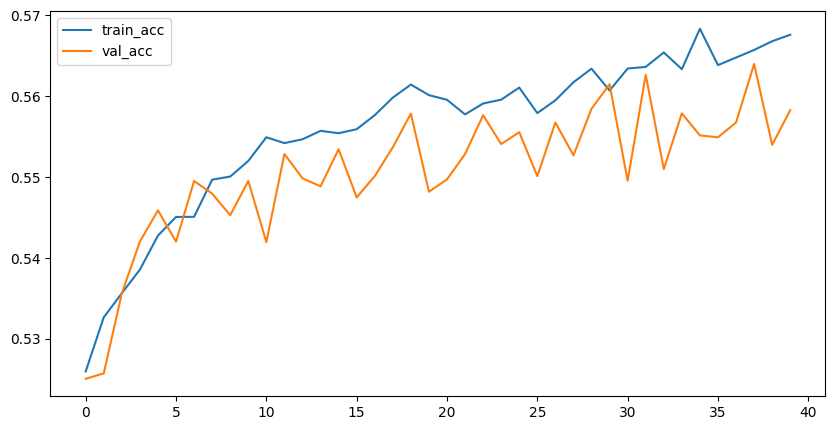

In [ ]:
# 학습 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.plot(his_rnn.history['accuracy'], label = 'train_acc')
plt.plot(his_rnn.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

In [ ]:
# 4.예측
pred = model.predict(X_test_vec)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
# 이진분류(sigmoid) -> 0.5를 기준으로 클래스 나누기
pred_cls = (pred > 0.5).astype('int')
pred_cls

array([[1],
       [1],
       [0],
       ...,
       [0],
       [0],
       [1]])

In [ ]:
y_test_sample = y_test.copy()

In [ ]:
y_test_sample = pd.DataFrame(y_test_sample) # 2차원 df로 만든 후

In [ ]:
y_test_sample['rnn_pred_cls'] = pred_cls # 컬럼 추가


In [ ]:
y_test_sample # 실제답, rnn이 예측한 클래스 값

,label,rnn_pred_cls
0,1,1
1,0,1
2,0,0
3,0,0
4,0,0
...,...,...
49995,1,0
49996,0,0
49997,0,0
49998,0,0


In [ ]:
# 모델 평가
model.evaluate(X_test_vec,y_test)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5587 - loss: 0.6562


[0.6585378646850586, 0.5577134490013123]

# SimpleRNN(바닐라RNN)의 경우 긴 시퀀스를 가진 데이터를 효과적으로 학습하기 어려움
- 순환횟수(시퀀스)가 길어질수록 초반에 입력된 단어의 기억데이터가 소실되는 기울기 소실 현상이 발생함.
- 문장 구성 시 초반 단어가 후반 예측에 영향을 주는 경우 바닐라RNN(일반RNN)이 학습하기 어려움


# 06-23

# LSTM (Long Short Term Memory)
- 장기기억과 단기기억을 관리하는 계산이 추가된 RNN 모델
- 기존 RNN 구조에서 메모리 셀(Cell)이라는 개념이 추가됨
- 가중치를 통해 중요한 기억은 오래, 그렇지 않으면 줄여서 관리
- Forget, Input, Output 게이트를 사용함

In [ ]:
from tensorflow.keras.layers import LSTM

# LSTM 모델링

In [ ]:
# 모델 설계
lstm_model = Sequential()
lstm_model.add(InputLayer(shape=(10,1)))
lstm_model.add(LSTM(units=64))
lstm_model.add(Dense(units=1, activation='sigmoid'))

# 모델 학습 및 평가방법 설정
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [ ]:
# 모델 학습
lstm_his = lstm_model.fit(X_train_vec, y_train,
                          validation_split=0.2,
                          epochs=40, batch_size=128)

In [ ]:
# 학습 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(lstm_his.history['accuracy'], label='train_acc')
plt.plot(lstm_his.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

# GRU (Gated Recurrent Unit)
- LSTM의 복잡성을 줄인 순환 신경망(RNN)의 변형
- Reset Gate, Update Gate 두 가지만 사용
- 셀 상태(Cell state) 없이 은닉 상태(hidden state)하나만 관리

# GRU 모델링

In [ ]:
from tensorflow.keras.layers import GRU

In [ ]:
# 모델 설계
gru_model = Sequential()
gru_model.add(InputLayer(shape=(10,1)))
gru_model.add(GRU(units=64))
gru_model.add(Dense(units=1, activation='sigmoid'))

# 모델 학습 및 평가방법 설정
gru_model.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [ ]:
# 모델 학습
gru_his = gru_model.fit(X_train_vec, y_train,
                          validation_split=0.2,
                          epochs=40, batch_size=128)

In [ ]:
# 학습 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(gru_his.history['accuracy'], label='train_acc')
plt.plot(gru_his.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 워드 임베딩
- 인공지능 기반의 텍스트 마이닝, 자연어처리 모델링을 할 때 입력되는 데이터의 수치화가 필요
- 현재 라벨 인코딩 기반의 수치화는 모델이 단어의 빈도 패턴을 학습하는 것과 비슷
- 단어의 본질적인 의미를 파악할 수 있도록 수치화를 정교하게 해보자
- 워드 임베딩 : 단어 > 벡터. 표현 방법, 단어를 밀집 표현으로 변환

# word2vec 맛보기

In [ ]:
!pip -q install -U gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


# gensim : 텍스트마이닝, NLP 분야에 유용한 패키지

In [ ]:
import gensim.downloader as api

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
api.info()

In [ ]:
# 사용 가능한 여러 모델 리스트 업
for model_name, model_data in sorted(api.info()['models'].items()):
  # num_records : 모델이 학습가능한 전체 단어 벡터 수
  num_records = model_data.get('num_records', -1)
  description = model_data['description'][:40] + '...'

  print( f'{model_name} ({num_records} records: {description})')

In [ ]:
# word2vec-google-news-300 로드
model = api.load('word2vec-google-news-300')
# 300만 개의 단어 벡터 포함, 각 단어는 300차원 벡터로 표현

In [ ]:
# .most_similar() : 유사도를 계산하여 주어진 단어와 벡터 공간상 가장 가까운 단어들 나열
# 기본 코사인 유사도 점수 (-1~1 사이의 값, 동일한 방향(유사)일수록 값은 1에 가까워짐)
model.most_similar("cat")

In [ ]:
# 두 벡터 사이의 유사성을 계산하는 함수
model.most_similar_cosmul(positive=['father', 'woman'], negative='man')

In [ ]:
model.most_similar_cosmul(positive=['soju', 'mexico'], negative='korea')

In [ ]:
from tensorflow.keras.layers import Embedding, LSTM
import numpy as np
import tensorflow as tf

In [ ]:
X_train_vec.shape, X_test_vec.shape

((149995, 10, 1, 1), (49997, 10, 1, 1))

In [ ]:
# 학습데이터(3차원)의 마짐가 차원 제거 > 2차원 변경
X_train_vec = tf.reshape(X_train_vec, [149995, 10])
X_test_vec = tf.reshape(X_test_vec, [49997, 10])

# RNN 계열 층 여러개 쌓기
- RNN계열 레이어는 기본적으로 다수입력 단일출력 구조
- RNN계열 레이어를 여러 층 쌓으려면 이전 레이어를 다수입력 다수출력 구조로 변경
- teturn_seqeunces = True 옵션 활용

In [ ]:
from tensorflow.keras.layers import GRU, Embedding

In [ ]:
# 모델 설계
model_embedding = Sequential()
model_embedding.add(Embedding(5000,50)) # 사용하는 단어 종류 수, 한 단어를 50개 숫자로 표현
model_embedding.add(GRU(128, return_sequences = True))
model_embedding.add(GRU(128))
model_embedding.add(Dense(1, activation='sigmoid'))

# 모델 학습 및 평가방법 설정
model_embedding.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [ ]:
y_train_clean

,document
0,더빙 진짜 짜증나다 목소리
1,흠 포스터 보고 초딩 영화 줄 오버 연기 가볍다 않다
2,무재 밓었 다그 래서 보다 추천
3,교도소 이야기 구먼 솔직 재미 없다 평점 조정
4,몬페 익살스럽다 연기 돋보이다 영화 스파이더맨 늙다 보이다 하다 커스틴 던스트 이쁘...
...,...
149995,인간 문제 소 죄인
149996,평점 낮다
149997,뭐 한국인 거들다 먹거리 필리핀 혼혈 착하다
149998,청춘 영화 최고봉 방황 우울하다 날 자화상


In [ ]:
# 모델 학습
emb_his = model_embedding.fit(X_train_vec, y_train,
                          validation_split=0.2,
                          epochs=40, batch_size=128)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7425 - loss: 0.4900 - val_accuracy: 0.8142 - val_loss: 0.4035
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8249 - loss: 0.3818 - val_accuracy: 0.8176 - val_loss: 0.3939
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8370 - loss: 0.3583 - val_accuracy: 0.8148 - val_loss: 0.3937
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8498 - loss: 0.3325 - val_accuracy: 0.8186 - val_loss: 0.3955
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8595 - loss: 0.3113 - val_accuracy: 0.8186 - val_loss: 0.4065
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8693 - loss: 0.2906 - val_accuracy: 0.8145 - val_loss: 0.4249
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8797 - loss: 0.2726 - val_accuracy: 0.8099 - val_loss: 0.4551
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8885 - loss: 0.2548 - val_accuracy:

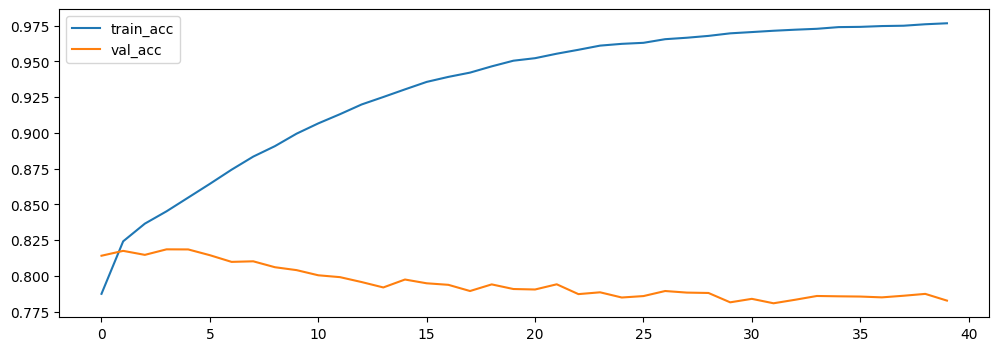

In [ ]:
# 학습 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(emb_his.history['accuracy'], label='train_acc')
plt.plot(emb_his.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
y_pre = model_embedding.predict(X_test_vec)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:
# 분류평가지표 확인
from sklearn.metrics import classification_report

In [ ]:
# 모델의 출력값 -> 학률값 (출력층의 활성화함수인 'sigmoid' 통과 -> 0~1사이 확률 값)
# 0.5보다 크면 1 아니면 0 반환 (이진 분류 정답으로 만들어주기)
y_pre = np.where(y_pre > 0.5,1,0)

In [ ]:
print(classification_report(y_test.values,y_pre))

              precision    recall  f1-score   support

           0       0.78      0.77      0.78     24826
           1       0.78      0.79      0.78     25171

    accuracy                           0.78     49997
   macro avg       0.78      0.78      0.78     49997
weighted avg       0.78      0.78      0.78     49997



In [ ]:
# test 정확도 0.78
# 정밀도, 재현율 모두 클래스 별 조금의 차이는 있지만, 전반적으로 균형 잡힌 성능을 보임